'''
강의자료를 예습하고 마크다운으로 정리해주세요!

---

- 추천 시스템의 분류
    - 내용 기반 필터링
    - 협업 필터링
        - 메모리 기반 협업 필터링
        - 모델 기반 협업 필터링
- 유사도
- 사용자 프로필
- TF-IDF

---

- 행렬 분해(Matrix Factorization)
    - 행렬 분해의 대표적 4가지 방식
- 딥러닝 기반 모델
    - VAE 기반 모델
    - GNN 기반 모델
    - Transformer 기반 모델  

    '''

# **추천 시스템 기초**
## 추천 시스템이란?
> 사용자의 정보 데이터를 분석하여 개인의 취향에 맞는 아이템을 추천하는 알고리즘
### [사용되는 데이터의 종류와 특징]
- 명시적 데이터: 고객들에 의해 선호도를 **직접적으로** 표현된 데이터
    - 장점: 당시 사용자의 취향을 정확하게 반영
    - 단점: 사람의 취향은 고정적이지 x -> 데이터 자체를 얻기 힘듦
- 암시적 데이터: 고객들의 행동을 기반으로 **간접적으로** 수집된 데이터
    - 장점: 데이터를 얻기 쉬움
    - 단점: 사용자의 취향이나 선호도를 직접적으로 알 수 X

### [추천시스템의 분류]
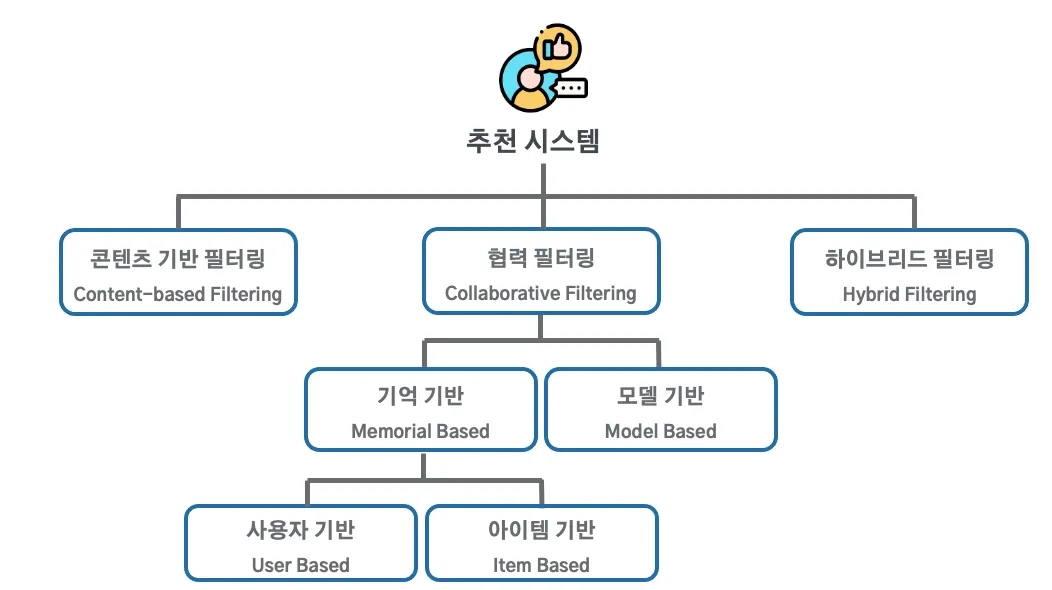  
- 내용 기반 필터링: **콘텐츠의 유사도**를 기반으로 사용자에게 추천하는 방법 -> **한 사용자의 행동 이력**을 기준으로 추천
- 협업 필터링: 서비스 내에 있는 **다수의 사용자로부터 얻은 선호도 정보**를 기반으로 사용자에게 추천하는 방법 -> **여러 사용자의 선호도**를 활용하여 추천
    - 사용자 기반: 특정 사용자와 유사한 취향의 사용자가 선호한 아이템 추천
    - 아이템 기반: 사용자가 선호한 아이템과 유사한 아이템 추천
- 하이브리드 필터링: 2가지 이상의 추천시스템 알고리즘을 조합하여 만든 알고리즘 -> 각각의 단점 보완

## 내용 기반 필터링
### [사용자 프로필]
- 개념: 추천 시스템에 사용되는 **데이터**
- 종류
    - **직접** 지정형: 사용자에게 자신이 **선호하는 아이템의 특징을 명시적으로 지정**하도록 하는 방법 -> 사용자가 지정
    - **간접** 지정형: 사용자의 **과거 행동 이력에 기반**하여 사용자의 프로필을 작성하는 방법 -> 제3자가 지정
> 사용자의 프로필을 획득하는 방식  
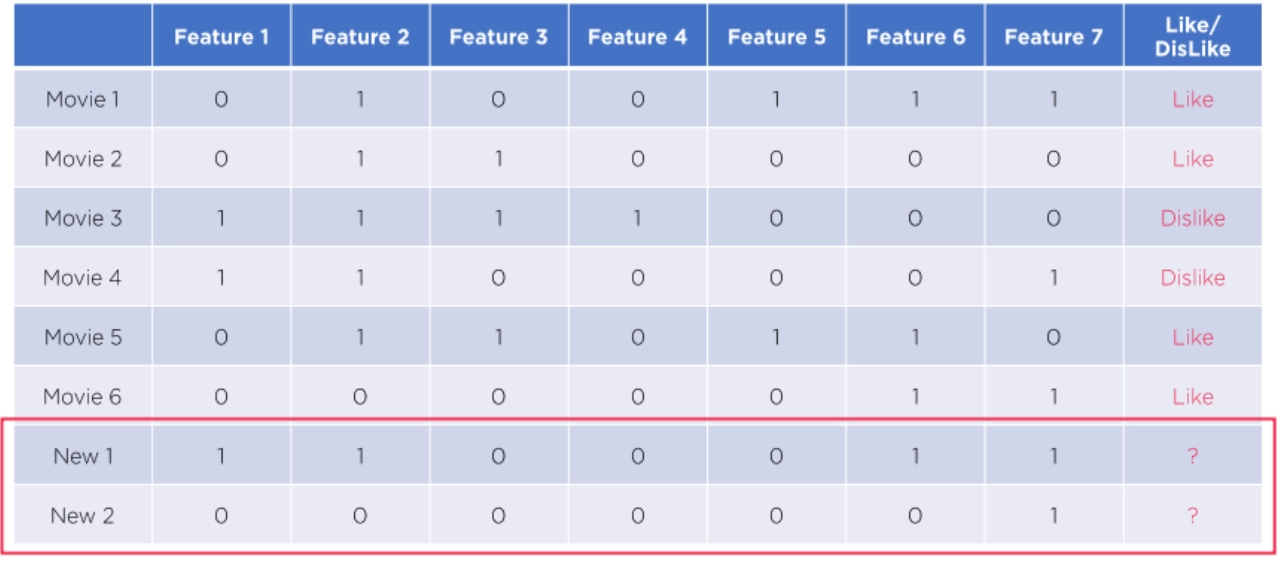

- 방법 1) 특성 가중치는 사용자가 가지고 있는 아이템 특성 가중치의 평균값을 활용
    - 사용자 프로필 = 아이템 특성 벡터 평균
    - 새로운 영화가 들어왔을 때, 그 영화의 특성 벡터와 유저 프로필 벡터의 유사도(코사인 유사도 등) 를 비교해서 추천 여부를 결정
- 방법 2) 사용자의 기호를 따로 파악하거나, 설문조사 또는 자발적인 키워드 입력 등으로 프로필 획득
- 방법 3) 아이템에 대한 유저의 기존 평가를 바탕으로 분류 문제를 해결하는 것과 동일
    - 주어진 유저 프로필을 바탕으로 새로운 아이템을 유저가 평가한 metric 중 하나 선택

### [유사도]
- 아이템 정보 데이터를 벡터화 -> 벡터 간 유사도 측정 -> 고객이 선호하는 아이템과 유사도가 높은 아이템 선별
- 단계  
    1. 인풋 데이터 만들기
        - 아이템 정보 활용 (=feature)
        - 테이블 형태로 데이터 정리: 행 = 아이템 이름 / 열 = 아이템 feature / 셀 = feature 값
        - 텍스트 데이터를 숫자로 변환 (원핫인코딩)
    2. 유저 정보 활용
        - 유저의 취향 파악
        - 유저와 아이템을 동일한 기준의 feature n개로 표현 -> 벡터 계산 가능
    3. 벡터 내적과 유사성
        - 내적값이 클수록 두 벡터의 유사성 높음
- **TF-IDF**(Term Frequency - Inverse Document Frequency)
    - 특정 문서 내에서 특정 단어의 빈도수(**TF**)와 전체 문서에서 특정 단어의 빈도수(**IDF**) 계산 -> **다른 문서에서는 등장하지 않지만 특정 문서에서만 자주 등장하는 단어**를 찾아서 문서 내 단어의 가중치
    - 각 단어가 그 문서에서 얼마나 중요한지

### [장단점]

| **장점** | **단점** |
| --- | --- |
| 아이템이 가지고 있는 **feature 자체**에만 집중하기 때문에 다른 유저의 평점 등에 영향을 받지 않음 → **콜드스타트 문제**에서 자유로움 | item의 feature를 추출해야 하고 이를 통해서 추천 하기 때문에 **정확한 feature를 추출하지 못하면 정확도가 떨어짐** |
| item의 feature를 통해서 추천을 하기 때문에 추천이 된 이유를 설명하기 용이함 | 기존의 item과 유사한 item 위주로만 추천하기에  **새로운 장르의 item을 추천하기 어려움** |

→ **Cold start problem** : 추천 시스템이 새로운 유저들에 대한 충분한 정보가 수집된 상태가 아니라서, 해당 유저들에게 적절한 제품을 추천해주지 못하는 문제


## 협업 필터링
### [메모리 기반 협업 필터링과 그 한계]
- 사용자 또는 아이템 간 유사도 기반 -> 특정 사용자와 비슷한 취향을 가진 사용자가 선호하는 아이템 추천
- **사용자 기반**(UBCF): **특정 사용자와 타 사용자 간의 유사도**를 측정한 뒤 가장 유사도가 높은 TOP-N 사용자를 추출해 그들이 선호하는 아이템을 추천
    - 추천 정확성 및 효율성: **아이템 수 > 사용자 수**일 때 유리
    - 안정성: **아이템이 수시로 바뀌는 환경**에 적합
    - 다양성: 특정 사용자가 독특한 아이템을 평가한 경우 **참신**한 아이템 추천 가능
    - 뉴스, 소셜 미디어, 음악 초기 모델에서 주로 활용
- **아이템 기반**(IBCF): **사용자들이 그 아이템을 좋아하는지/싫어하는지의 평가 척도가 유사한 아이템**을 추천하는 기준이 되는 알고리즘
    - 추천 정확성 및 효율성: **아이템 수 < 사용자 수**일 때 유리
    - 안정성: **아이템이 고정적인 환경**에 적합
    - 다양성: 유사 아이템 위주 추천 -> 다양성, 참신성 부족
    - 계산 속도가 빠르고 안정적
    - 아마존, 넷플릭스에서 활용
- 한계
    - 희소 행렬 문제: 주어진 평점/선호도 데이터가 적을 경우 성능 저하 -> model-based CF 활용
    - 확장성 문제: 아이템/유저가 계속 늘어날 경우 확장성 저하 -> KNN CF 활용
    - 콜드 스타트 문제: 데이터가 아예 없는 경우
        | 유형 | 상황 | 설명 |
        | --- | --- | --- |
        | **User Cold Start** | 신규 유저 유입 | 평가 이력이 없어 유사 유저 탐색 불가 |
        | **Item Cold Start** | 신규 아이템 등록 | 아무도 평가하지 않아 유사도 계산 불가 |

        -> 직접 지정형 프로필 활용, content-based filtering, 인구통계학적 정보 활용

### [모델 기반 협업 필터링]
- 개념: 데이터로부터 관측된 평점을 학습한 모델을 만들어 관측되지 않은 평점 예측 -> **데이터 뒤에 숨겨진 패턴을 학습해 추천의 정확도와 확장성을 동시에 향상**
- 잠재 요인: 취향, 성향, 특징 등 실제 데이터에는 없지만, 관측된 데이터(평점 패턴)을 분석하여 수치로 추정할 수 있는 값
- Latent Factor Model: 주어진 데이터로는 알 수 없는 사용자-아이템 간의 숨겨진 특성을 찾기 위해 **주어진 Matrix를** **사용자-잠재요인**, **아이템-잠재요인**으로 **각각 분해**하여 학습하는 모델
    - 일반 factor model: 유저와 아이템 구분 x. 동일한 차원의 벡터 공간에 좌표로 표현헤서 서로의 거리나 각도로 유사도 파악
    - latent factor model: 사용자와 아이템을 보이지 않는 축(=잠재적인 차원)들을 사용해 나타낼 수 있고, 이를 통해 평점을 예측
- 행렬 분해 (Matrix Factorization)  
![factors](https://miro.medium.com/v2/resize:fit:1276/1*pNXo4Zj_QOZLS0a2mu5OSg.jpeg)  
    - 유저-아이템 행렬을 분해해 평점을 유저의 잠재요인과 아이템의 잠재요인의 내적으로 설명 -> 이를 통해 평점 예측
    - 종류  
        | **구분** | **접근 방식** | **특징** |
        | --- | --- | --- |
        | **SVD** | **수학적 분해 기법** | 행렬 대수학에 기반. 희소 행렬에는 직접 적용 불가하여 결측치 처리 필요. |
        | **SGD** | **최적화 알고리즘** | 경사 하강법 기반. 관측된 평점에 대해서만 학습 진행 -> 희소성 문제를 우회적으로 해결. |
        | **NMF** | **제약 조건 기반 모델** | 분해된 행렬에 비음수(Non-Negative)라는 제약 조건을 추가 -> 잠재 요인의 해석력 향상. |
        | **PMF** | **확률적 모델** | 평점 예측에 확률 분포 사용 -> 불확실성까지 모델링하는 통계적 접근법입니다. → VAE와 연결 |
    - SVD: 특이값 분해. A = 사용자-아이템 평점 행렬, U = 사용자 관련 정보, Σ = 특이값 행렬, $V^T$ = 아이템 관련 정보 $$A=UΣV^T$$
        - Full SVD: 모든 특이값과 벡터 사용. dense matrix에 적합
        - Truncated SVD: 상위 k개의 큰 특이값과 해당 벡터만 사용. sparse matrix 압축 및 노이즈 제거에 적합
    - SGD: 목적함수를 통해 오차의 제곱합 최소화. 정규화 항을 통해 과적합 방지
    - NMF: 분해된 두 개의 행렬의 모든 원소가 0 이상. 직관적
    - PMF: 누가 무엇을 좋아할지 확률적으로 예측. 베이지안 추론 기법과 결합

# **딥러닝 기반 추천 시스템**
## VAE 기반 협업 필터링
- 사용자의 아이템 상호작용 벡터를 입력으로 받아 잠재 공간에서 재구성하도록 VAE 학습
- 구조  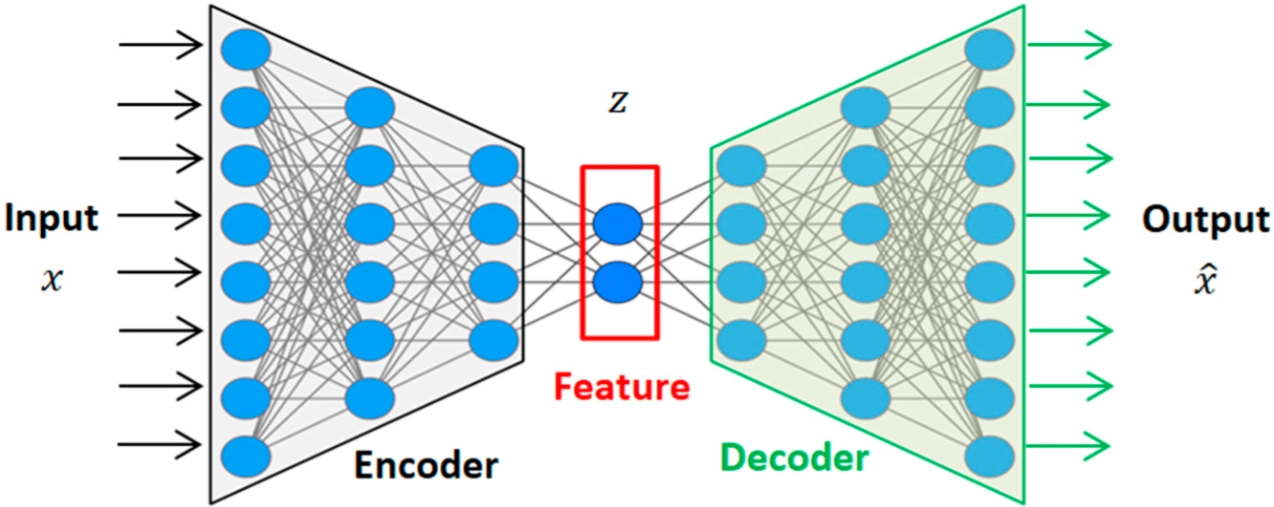  
    - 인코더: 사용자 이력을 잠재변수 z 분포로 매핑
    - 디코더: z로부터 아이템 분포 복원
- 장점: 기존 MF와 달리 확률적 잠재 분포로 사용자 선호 모델링 -> 불확실성 반영 / 희소한 상호작용 데이터에서도 사용 가능
### [MF의 한계와 딥러닝의 등장]
- 선형성의 한계: 평점 예측이 단순한 잠재벡터의 내적으로만 이루어짐 -> 딥러닝: 비선형 활성화 함수를 가진 신경망을 사용해 복잡한 패턴 학습
- 불확실성 무시: 사용자의 취향을 단 하나의 벡터값으로 표현 -> 딥러닝: 확률 분포로 취향 모델링(불확실성 반영)
### [Why VAE?]
- VAE(Variational AutoEncoder)는 불확실성을 모델링 -> 희소성(Sparsity)에 대한 해답 제시
- 
    | 구분 | AutoEncoder (AE) | Variational AutoEncoder (VAE) |
    | --- | --- | --- |
    | **잠재 벡터 표현** | 단일 값 (Point Estimate) | **확률 분포** (평균 $\mu$, 분산 $\sigma$) |
    | **데이터 불확실성** | 반영 불가 (단순 복원에 집중) | **데이터의 불확실성을 모델링**하여 안정성 확보 |
    | **적용 시 장점** | 비선형성 학습 | 희소한 데이터에서 더욱 안정적이며, 일반화 성능 우수 |
### [VAE 기반 CF (Mult-VAE)의 작동 구조]
- 사용자의 아이템 상호작용 벡터를 입력으로 받아 잠재공간에서 재구성하도록 학습하는 방식
- 구성
    - 입력: 사용자의 아이템 상호작용 벡터
    - 인코더: 사용자 이력을 잠재변수 z 분포로 매핑
    - 잠재벡터: 샘플링된 최종 취향 벡터
    - 디코더: z로부터 아이템 분포 복원
### [목적함수와 KL Divergence]
$$\mathcal{L}(x; \theta, \phi) = \underbrace{E_{q_\phi(z|x)} [ \log p_\theta(x|z) ]}_{\text{재구성 오차 최소화 (Reconstruction Loss)}} - \underbrace{D_{\text{KL}}(q_\phi(z|x) || p(z))}_{\text{잠재 공간 정규화 (KL Divergence)}}$$

- 목적함수 = **ELBO**(Evidence Lower Bound)
- 목적함수의 역할
    - **재구성 오차 최소화**: 디코더가 원래 입력과 최대한 비슷하게 복원하게 함
    - **KL Divergence**: 인코더가 출력하는 잠재 분포 $q(z|x)$가 사전 분포 $p(z)$ (표준 정규 분포)와 유사하도록 강제 -> 모델이 특정 데이터에 과적합하여 잠재 공간을 불규칙하게 만드는 것 방지
- 장점: **확률적 잠재 분포 모델링**(예측 시의 불확실성 반영, 노이즈에 자유로움), **희소한 상호작용 데이터에서도 유용**(잠재공간 정규화->희소성 문제에 효과적 대응), 비선형성 학습(신경망 구조 활용)

## GNN 기반 사용자 선호 예측
- VAE는 관계나 순서 정보 활용 X -> GNN 활용
### [GNN - Graphic Neural Network]
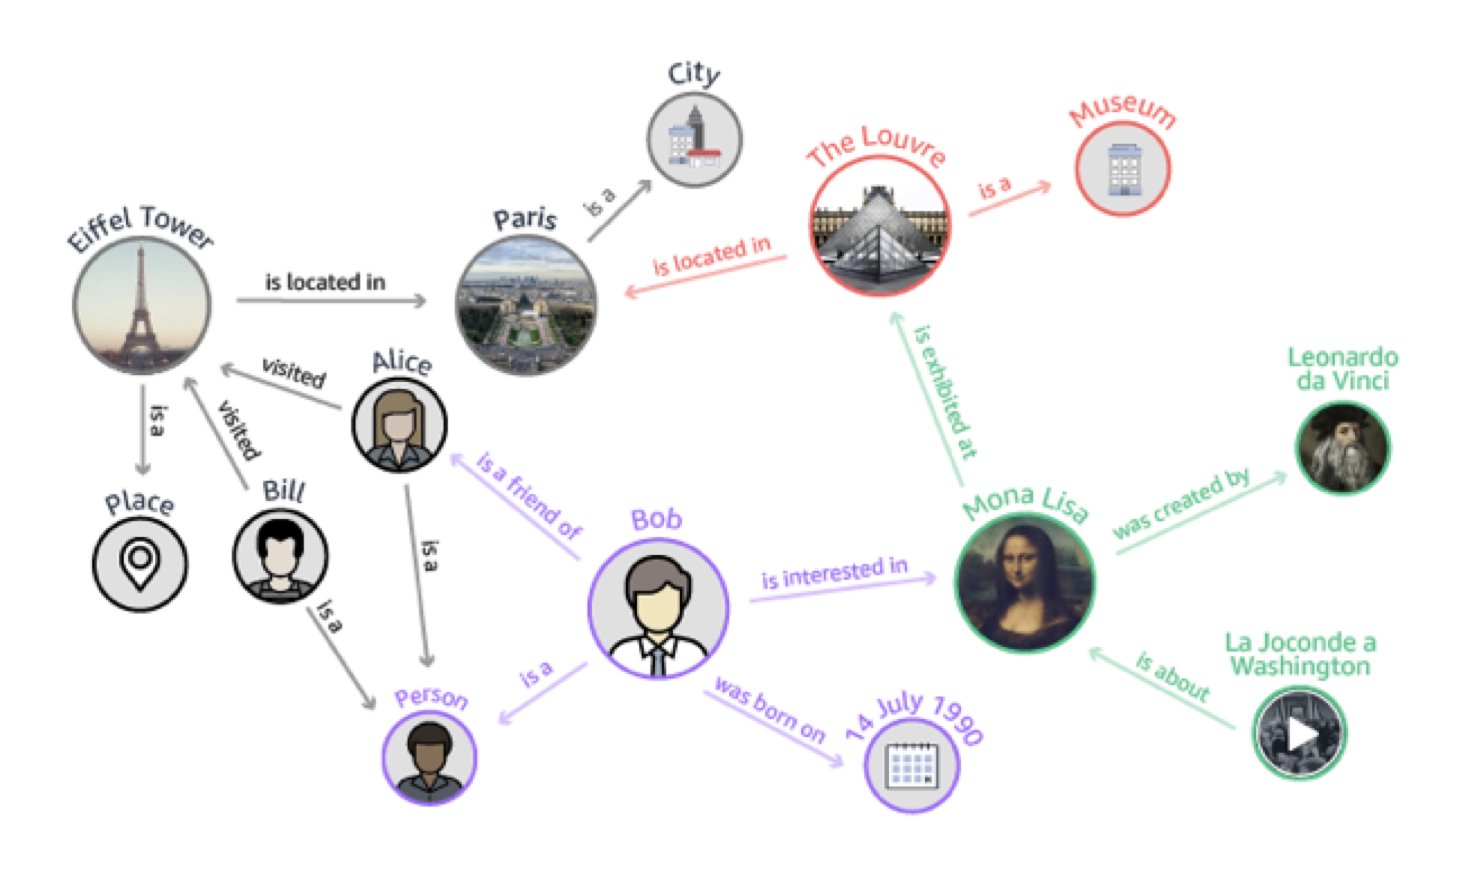  
- 사용자와 아이템의 상호작용을 서로 연결된 거대한 관계망 그래프로 봄
- 구조: 내 이웃 노드의 정보를 나에게 전달/요약
    - 그래프 구조 생성: 노드 = 개별 객체, 엣지 = 객체 간 관계나 연결성 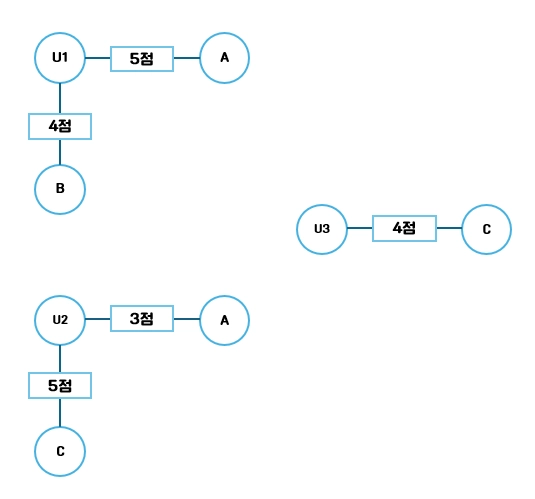  

    - 메시지 패싱: 각 노드가 이웃 노드로부터 정보를 전달 받아 전달 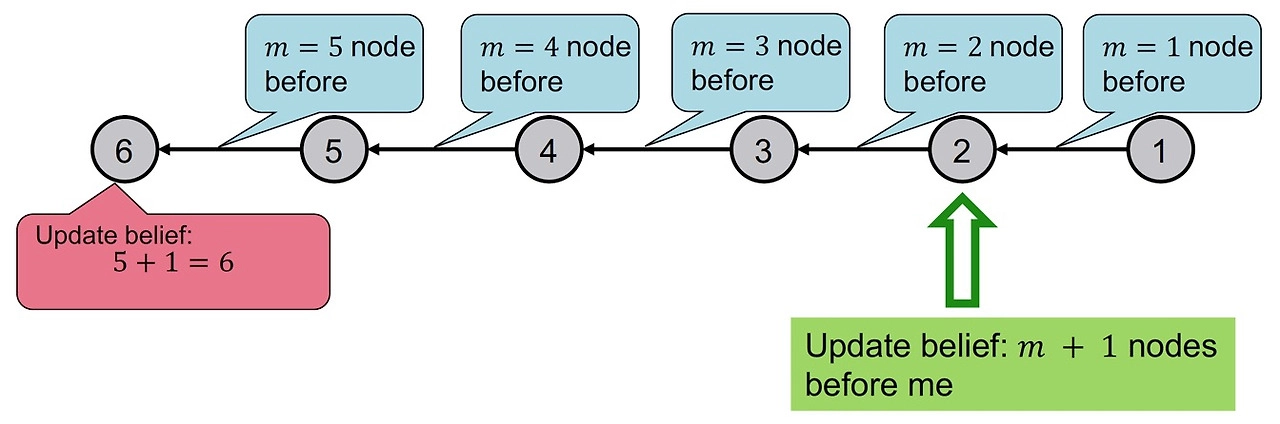  

        - 메시지 생성: 이웃 노드로 전달할 메시지 생성
        - 집계: 받은 여러 이웃의 메시지를 하나로 합침
        - 갱신: 자신의 노드 상태 업데이트
    - 최종 출력
- 프로세스 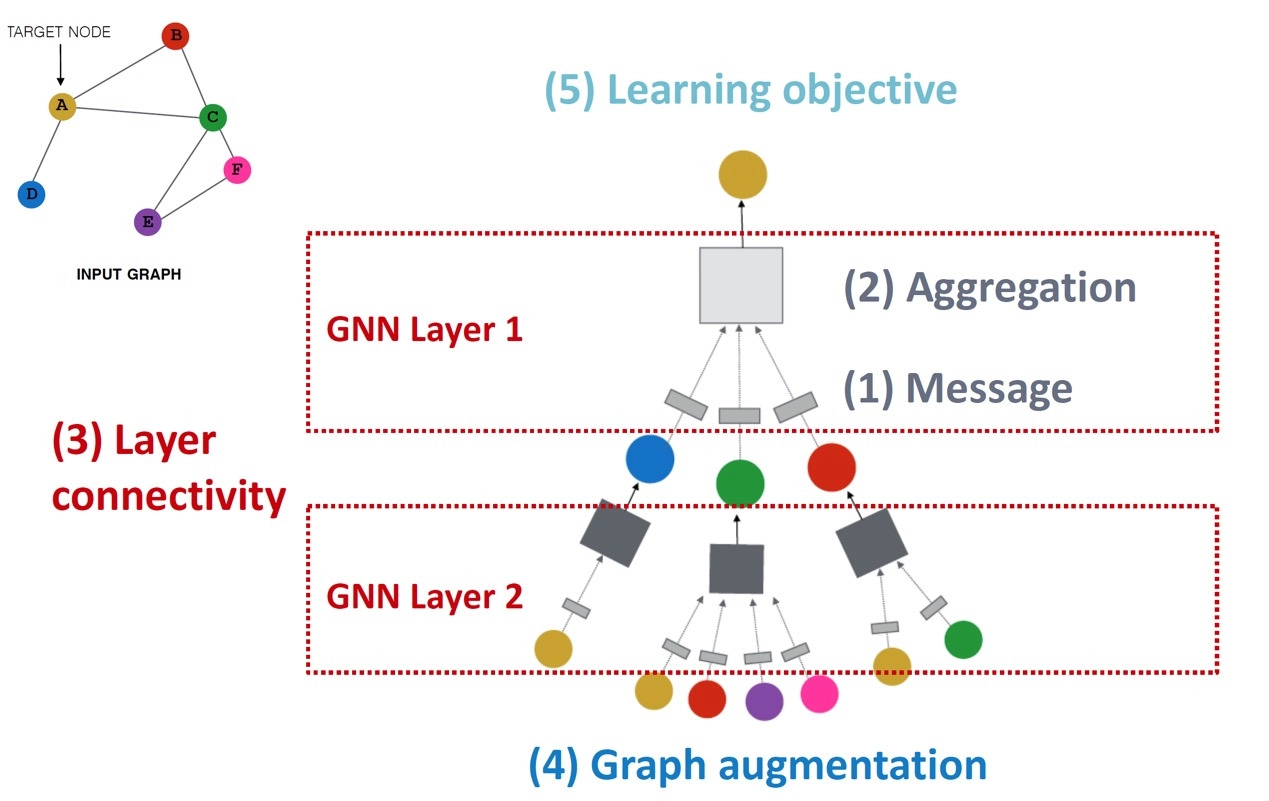  
    - 메시지 패싱: 각 노드는 자신의 이웃 노드들의 정보(잠재 요인)를 수집하여 자신의 은닉 상태(임베딩)를 업데이트
    - 위 과정을 K번 반복하여 더 멀리 있는 이웃 정보까지 반영
    - 이웃들의 취향까지 반영한 최종 임베딩을 얻어 두 노드 간 선호도 예측

### [LightGCN (Light Graph Convolutional Networks)]
- 메시지 계산 방법이나 집계 방식에 따라 GNN 아키텍쳐 결정
    - GCN (Graph Convolutional Network): 그래프 위에서 컨볼루션 연산 수행. 이웃 노드와 타겟 노드에 동일한 파라미터 적용 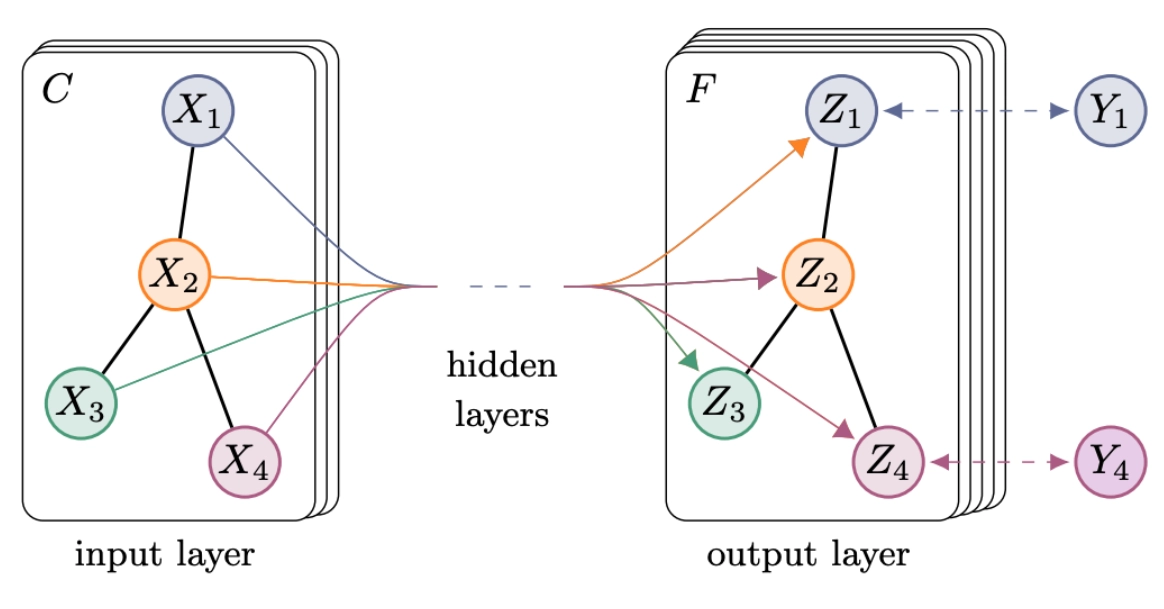  
    - GRN (Graph Recurrent Network) : RNN + GNN . 시간에 따라 노드 특성이 업데이트 되어 그래프의 동적 변화 포착 가능
    - GAT (Graph Attention Network) : 이웃 노드 간 중요도를 학습해 가중 평균. 타겟 노드의 이웃 노드 중 중요한 노드에 가중치 부여
    - GraphSAGE : 대규모 그래프에 대해 샘플링 기반으로 학습. 이웃 노드와 타겟 노드의 가중치 값을 더하지 않고, concatnate
- LightGCN 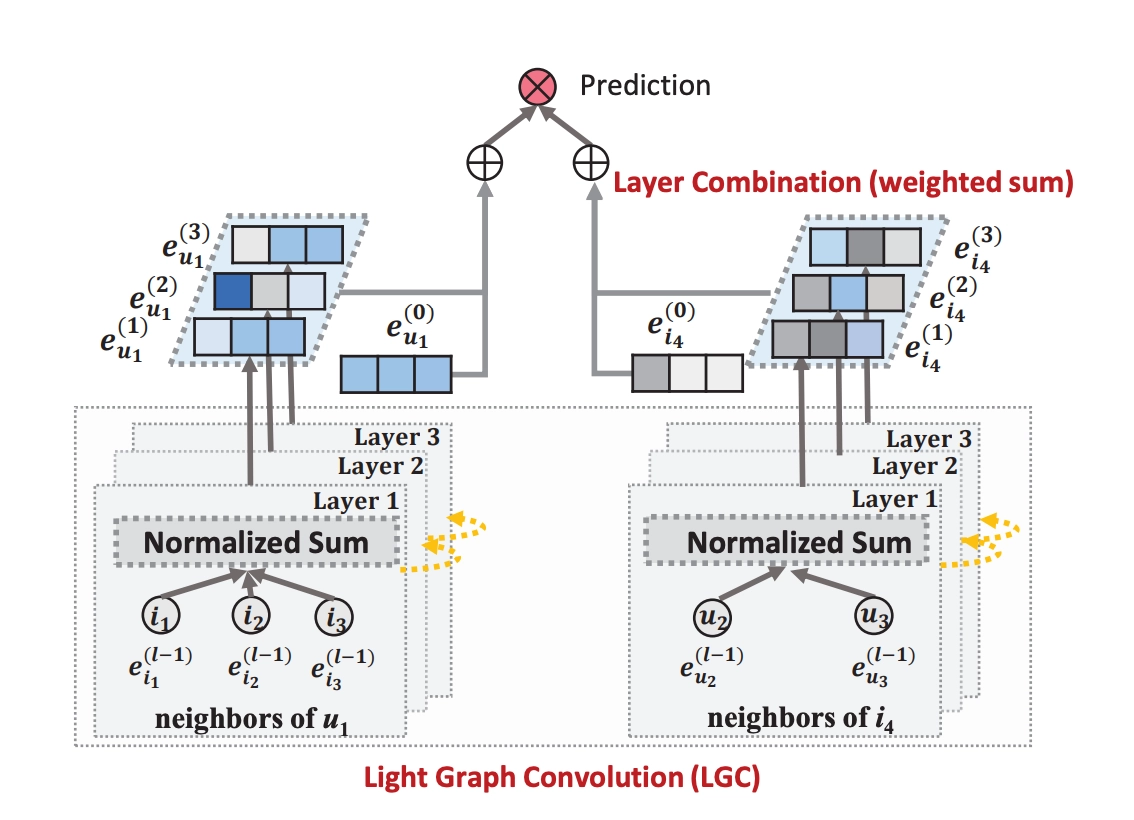  
    - 추천 시스템에 특화된 GNN. **합성곱 연산** 사용
    - **특징 변환 제거**: 레이어마다 복잡한 학습 파라미터 삭제
    - **비선형 활성화함수 제거**: 활성화 함수 사용 대신 이웃 정보를 합침 -> 주로 정규화된 합 혹은 평균 사용
    => **정규화된(Normalized) 이웃 임베딩의 합(Aggregation)만으로 구성**

### [GNN의 장단점]
- 장점
    - 고차원 협업 시그널 포착
    - 정형화되지 않은 데이터 학습 가능
    - cold start 문제 완화에 효과적
- 단점
    - 과평탄화 문제: 모든 노드의 임베딩이 같은 값으로 수렴
    - 과압축 문제
    - 높은 계산 복잡도
    - 해석의 어려움


## Transformer 기반 추천 시스템
### [기존 추천 시스템의 순차적 한계]
- CF의 순차적 한계: 구매 순서 고려 X, 문맥 부족(ex: 방금 구매한 아이템과 1년 전에 구매한 아이템의 중요도 구분 어려움), 예측의 한계
- GNN의 순차적 한계: 장기 의존성 문제
### [Transformer 모델 도입]
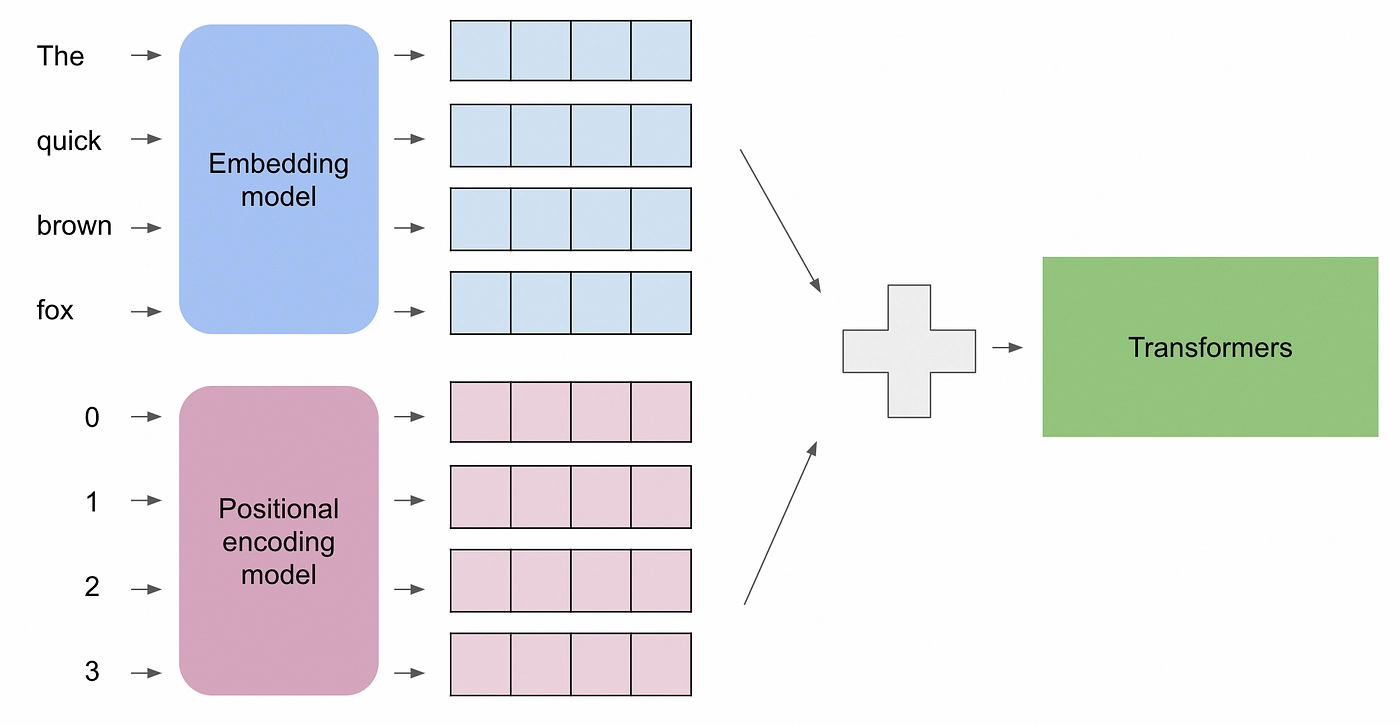  
- trnasformer: 시퀀스 내의 문맥과 핵심 의도 파악에 강력 -> 사용자 행동을 순서로 접근하는데 유리
- 주요 추천시스템 모델
    - SASRec: **단방향 어텐션**으로 **과거 정보만 활용하여 미래 행동을 추측**하는 방식 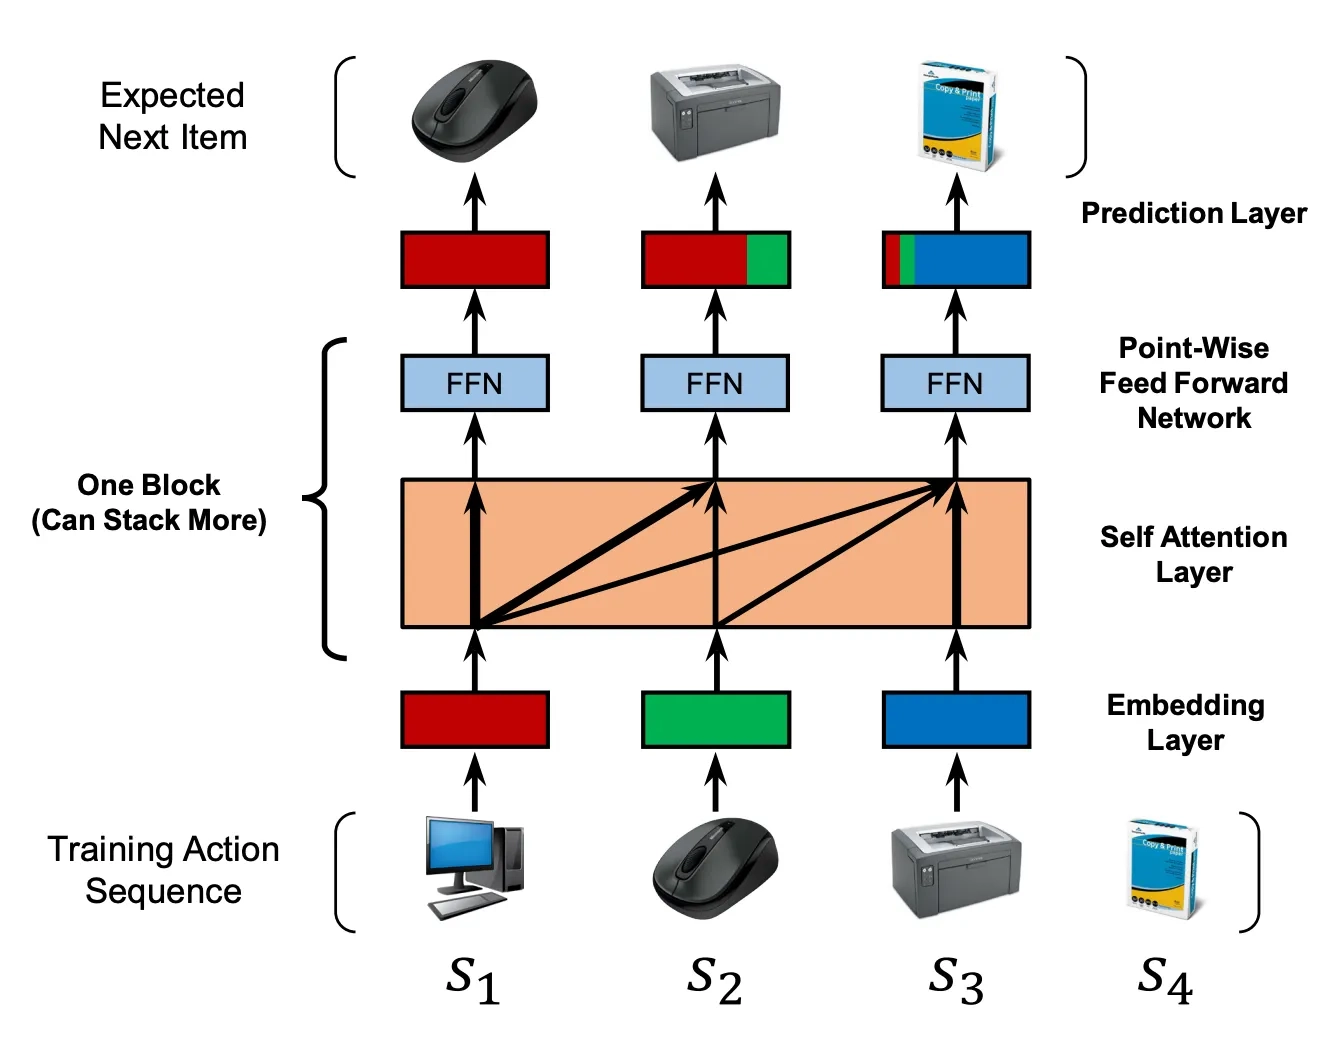  
        - 문제점: 계산량 많음, 단방향성
    - BERT4Rec: **양방향 어텐션**으로 **과거 정보와 미래 정보를 활용**하여 예측 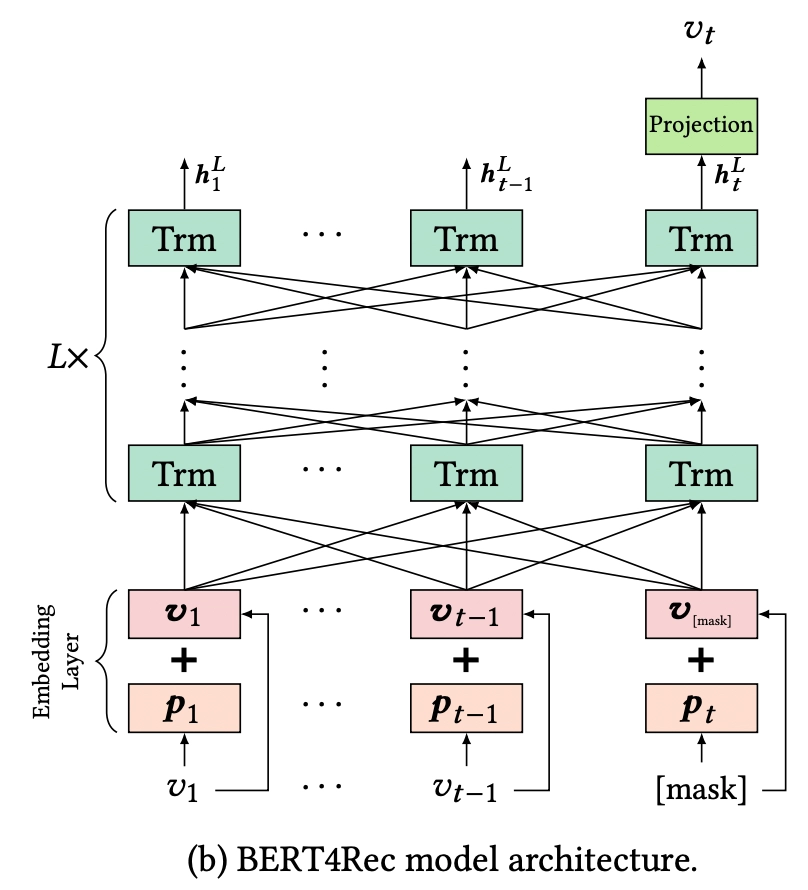  
        - 시퀀스 내 가려진 아이템을 예측하는 것이 목표
        - 학습 과정에서 시퀀스 전체의 선호도를 파악하는 데 더 초점